FEATURE ENGINEERING

In [30]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

import os
os.chdir("/Users/arttusokka/Documents/AThesis/Prediciting-ATP-matches-outcome/data")

df= pd.read_csv("/Users/arttusokka/Documents/AThesis/Prediciting-ATP-matches-outcome/data/clean_and_raw/atp_matches_2000_2019_clean.csv")
df_clean = df.copy()
df_clean["tourney_date"] = pd.to_datetime(df_clean["tourney_date"])

In [31]:
#RANDOMIZING THE WINNER AND LOSER COLUMNS
#-----------------------------------------------
#first, draw which side will be the winner.
np.random.seed(42)
mask = np.random.rand(len(df_clean)) < 0.5
#true -> winner -> player1, false -> winner -> player2


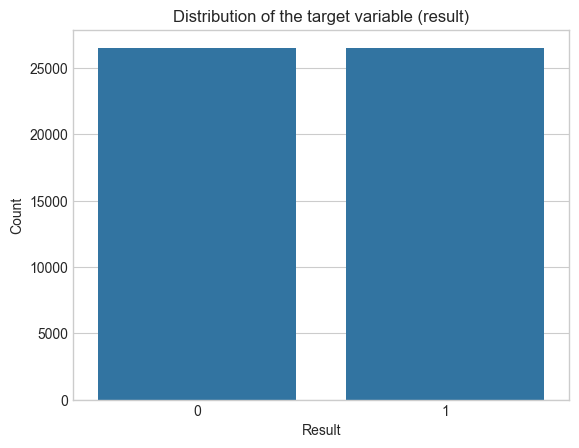

In [32]:
#differ winner and loser columns
winner_cols = [col for col in df_clean.columns if col.startswith("winner_")]
loser_cols = [col for col in df_clean.columns if col.startswith("loser_")]

#create player_1_ and player_2_ columns
for w_col in winner_cols:
    l_col = w_col.replace("winner_", "loser_")
    
    base_name = w_col.replace("winner_", "")
    
    df_clean[f"player1_{base_name}"] = np.where(
        mask,
        df_clean[w_col],
        df_clean[l_col]
    )
    
    df_clean[f"player2_{base_name}"] = np.where(
        mask,
        df_clean[l_col],
        df_clean[w_col]
    )

#target variable (if winner = player1 -> 1, else 0)
df_clean["result"] = np.where(mask, 1, 0)

#let's drop the original winner and loser columns.
df_clean = df_clean.drop(columns=winner_cols + loser_cols)

#Lastly, create a graph showing the distribution of the target variable.
sns.countplot(x="result", data=df_clean)
plt.title("Distribution of the target variable (result)")
plt.xlabel("Result")
plt.ylabel("Count")
plt.show()

In [33]:
#sort the data by date (already done in cleaning, but just to be sure)
df_clean = df_clean.sort_values("tourney_date").reset_index(drop=True)

#THE BASE DIFFERENTIAL VARIABLES
#1. Rank differential (1-2)
df_clean["rank_diff"] = df_clean["player1_rank"] - df_clean["player2_rank"]

#2. Rank points differential
df_clean["rank_points_diff"] = df_clean["player1_rank_points"] - df_clean["player2_rank_points"]

#3. Age differential (1-2)
df_clean["age_diff"] = df_clean["player1_age"] - df_clean["player2_age"]
#KÄYTÄ MYÖS IKÄMUUTTUJAA! normisti

#4. Height differential (1-2)
df_clean["height_diff"] = df_clean["player1_ht"] - df_clean["player2_ht"]
#5. Hand matchup dummy coding (1 if different, 0 if same). Could do more detailed
#but most likely wouldn't add much value because the only big difference is between same and different hand.
df_clean["different_hand"] = (
    df_clean["player1_hand"] != df_clean["player2_hand"]
).astype(int)


In [34]:
#ELO
ELO_START = 1500
K = 32
SCALE = 400
#Expected outcome Player 1 - Player 2
def expected_score(r1, r2, scale=400):
    return 1 / (1 + 10 ** ((r2 - r1) / scale))

#ELO change
def update_elo(r1, r2, score1, k=32, scale=400):
    e1 = expected_score(r1, r2, scale)
    r1_new = r1 + k * (score1 - e1) #playr1 elo update
    r2_new = r2 - k * (score1 - e1) #player2 elo update (note the minus, because score1 is from player1 perspective)
    return r1_new, r2_new

#Empty columns for pre-match ELO ratings
df_clean["elo_p1_pre"] = np.nan
df_clean["elo_p2_pre"] = np.nan

#ELO memory
elo_dict = {}
df_clean = df_clean.sort_values("tourney_date").reset_index(drop=True)

#Calculate ELO ratings iteratively
for i, row in df_clean.iterrows():
    
    p1 = row["player1_id"]
    p2 = row["player2_id"]
    score1 = row["result"]  # 1 = player1 wins
    
    #Current ELO or DEFAULT=1500
    r1 = elo_dict.get(p1, ELO_START)
    r2 = elo_dict.get(p2, ELO_START)
    
    #save pre-match ELO ratings
    df_clean.at[i, "elo_p1_pre"] = r1
    df_clean.at[i, "elo_p2_pre"] = r2
    
    #Update ELO
    r1_new, r2_new = update_elo(r1, r2, score1, k=K)
    
    elo_dict[p1] = r1_new
    elo_dict[p2] = r2_new
    
    #ELO differentials (1-2)
df_clean["elo_diff"] = df_clean["elo_p1_pre"] - df_clean["elo_p2_pre"]

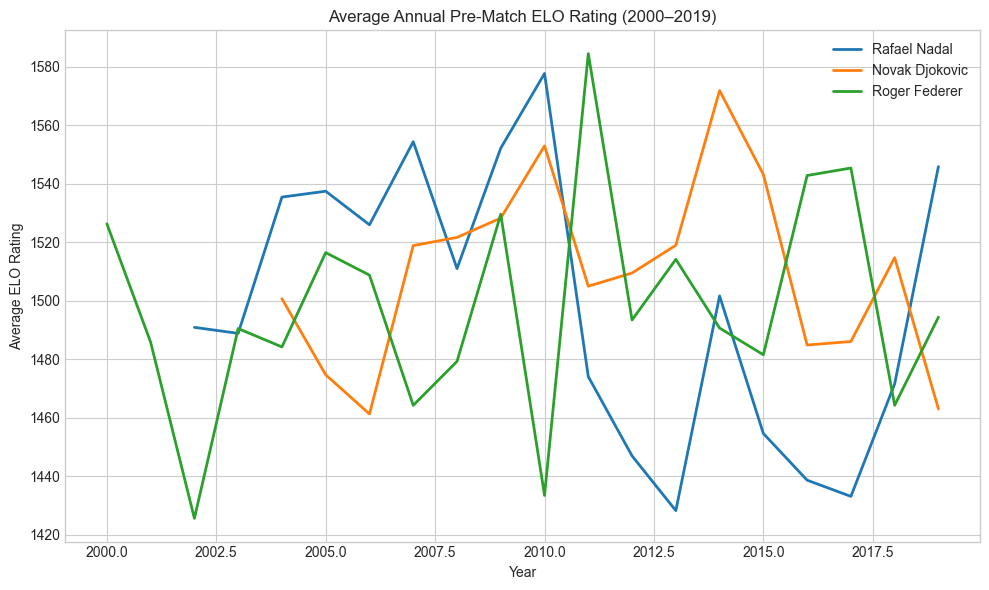

In [35]:

#
df_clean["year"] = df_clean["tourney_date"].dt.year

top_players = ["Rafael Nadal", "Novak Djokovic", "Roger Federer"]

plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(10,6))

for player in top_players:
    
    # Hae pelaajan ottelut
    player_rows = df_clean[
        (df_clean["player1_name"] == player) |
        (df_clean["player2_name"] == player)
    ].copy()
    
    # Valitse oikea pre-match ELO
    player_rows["elo"] = player_rows.apply(
        lambda row: row["elo_p1_pre"] 
        if row["player1_name"] == player 
        else row["elo_p2_pre"],
        axis=1
    )
    
    # Vuosi-keskiarvo
    yearly_mean = (
        player_rows
        .groupby("year")["elo"]
        .mean()
    )
    
    plt.plot(
        yearly_mean.index,
        yearly_mean.values,
        linewidth=2,
        label=player
    )

plt.title("Average Annual Pre-Match ELO Rating (2000–2019)")
plt.xlabel("Year")
plt.ylabel("Average ELO Rating")
plt.legend()
plt.tight_layout()
plt.show()


In [36]:
#SURFACE-SPECIFIC ELO RATINGS
#Empty columns for pre-match surface-specific ELO ratings
df_clean["elo_p1_pre_surface"] = np.nan
df_clean["elo_p2_pre_surface"] = np.nan
df_clean = df_clean.sort_values("tourney_date").reset_index(drop=True)


surface_elo_dict = {}
for i, row in df_clean.iterrows():
    
    p1 = row["player1_id"]
    p2 = row["player2_id"]
    surface = row["surface"]
    score1 = row["result"]  # 1 = player1 wins
    
    #Keys for surface-specific ELO
    key1 = (p1, surface)
    key2 = (p2, surface)
    
    #Current ELO or DEFAULT=1500
    r1 = surface_elo_dict.get(key1, ELO_START)
    r2 = surface_elo_dict.get(key2, ELO_START)
    
    #save pre-match surface-specific ELO ratings
    df_clean.at[i, "elo_p1_pre_surface"] = r1
    df_clean.at[i, "elo_p2_pre_surface"] = r2
    
    #Update ELO
    r1_new, r2_new = update_elo(r1, r2, score1, k=K)
    
    surface_elo_dict[key1] = r1_new
    surface_elo_dict[key2] = r2_new
    
#Surface-specific ELO differential feature
df_clean["elo_diff_surface"] = (df_clean["elo_p2_pre_surface"] - df_clean["elo_p1_pre_surface"])
df_clean.groupby("result")["elo_diff_surface"].mean()

result
0    0.149362
1    0.372804
Name: elo_diff_surface, dtype: float64

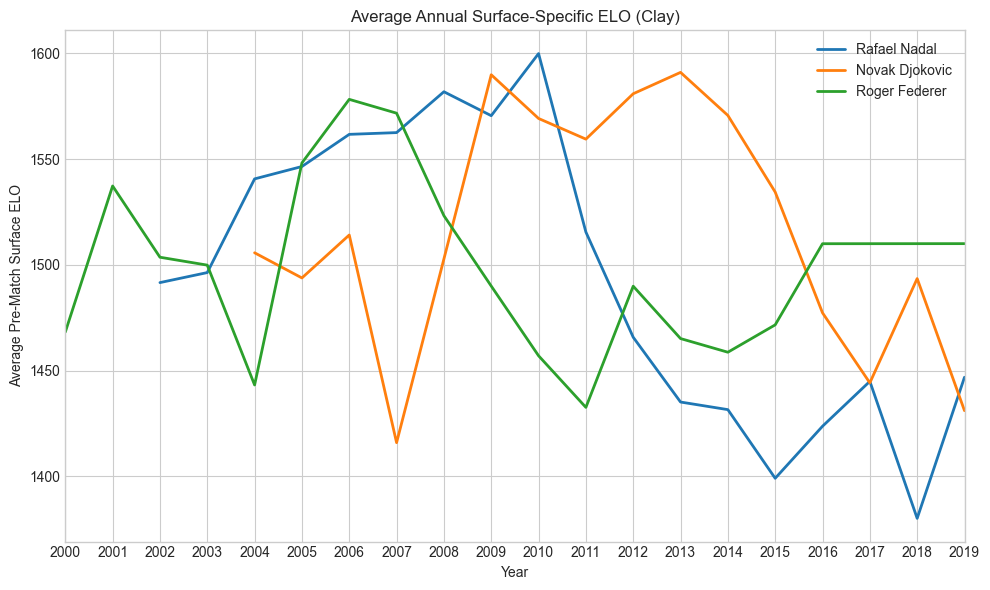

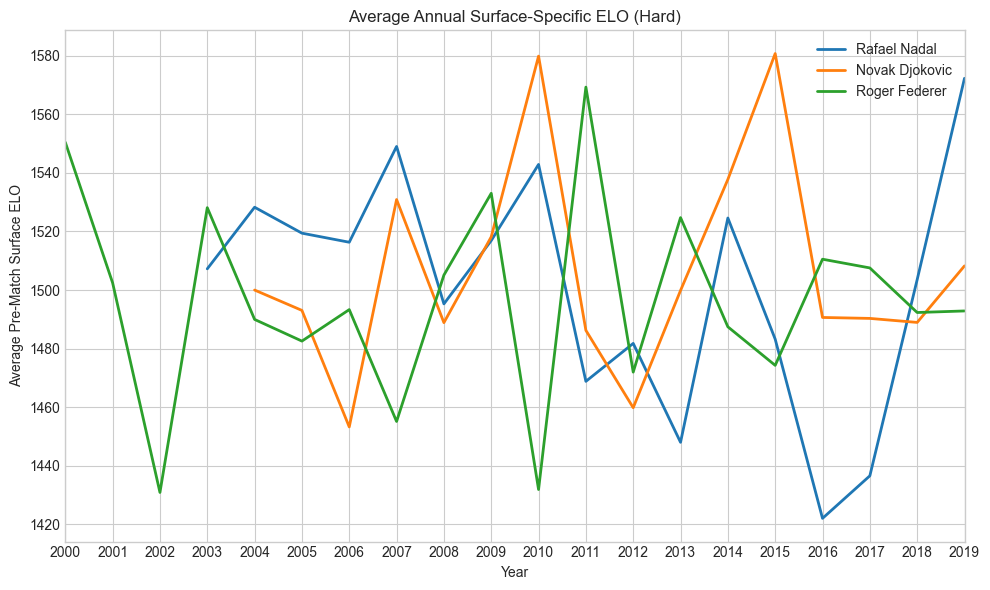

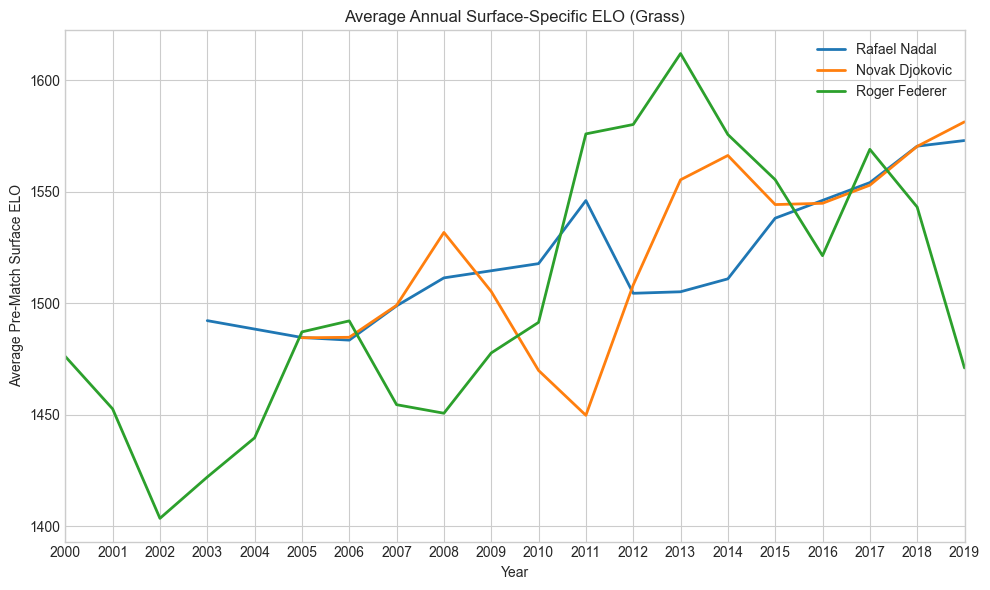

In [37]:
import matplotlib.pyplot as plt
import pandas as pd

# Varmista datetime
df_clean["tourney_date"] = pd.to_datetime(
    df_clean["tourney_date"], format="%Y%m%d"
)

# Luo year-muuttuja
df_clean["year"] = df_clean["tourney_date"].dt.year

top_players = ["Rafael Nadal", "Novak Djokovic", "Roger Federer"]
surfaces = ["Clay", "Hard", "Grass"]  # varmista että nimet vastaavat datasettiäsi

plt.style.use("seaborn-v0_8-whitegrid")

for surface in surfaces:
    
    plt.figure(figsize=(10, 6))
    
    for player in top_players:
        
        player_rows = df_clean[
            (
                (df_clean["player1_name"] == player) |
                (df_clean["player2_name"] == player)
            )
            & (df_clean["surface"] == surface)
        ].copy()
        
        # Valitse oikea surface-elo
        player_rows["elo_surface"] = player_rows.apply(
            lambda row: row["elo_p1_pre_surface"]
            if row["player1_name"] == player
            else row["elo_p2_pre_surface"],
            axis=1
        )
        
        yearly_mean = (
            player_rows
            .groupby("year")["elo_surface"]
            .mean()
            .sort_index()
        )
        
        plt.plot(
            yearly_mean.index,
            yearly_mean.values,
            linewidth=2,
            label=player
        )
    
    plt.title(f"Average Annual Surface-Specific ELO ({surface})")
    plt.xlabel("Year")
    plt.ylabel("Average Pre-Match Surface ELO")
    
    # Pakota vuodet 2000–2019 kokonaislukuina
    plt.xticks(range(2000, 2020))
    plt.xlim(2000, 2019)
    
    plt.legend()
    plt.tight_layout()
    plt.show()


In [39]:
#save the data
df_clean.to_csv("/Users/arttusokka/Documents/AThesis/Prediciting-ATP-matches-outcome/data/clean_and_raw/atp_matches_2000_2019_clean.csv", index=False)
